In [1]:
# Downloads
%pip install ftfy

In [2]:
# Imports
import re
import ftfy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split

In [3]:
# Read in fake data
true = pd.read_csv("Fake.csv")
true["outcome"] = "Fake"

# Read in true data
false = pd.read_csv("True.csv")
false["outcome"] = "True"

# Concatenate them together
all_data = pd.concat([true, false])
all_data = all_data.sample(frac = 1, random_state = 1).reset_index(drop = True)

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Forc...,Donald Trump is calling for one of the most co...,News,"September 21, 2016",Fake
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,"September 7, 2016",True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,"May 9, 2017",Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,"Jul 21, 2016",Fake
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,"October 14, 2017",True


In [4]:
# Get some information about the data
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   outcome  44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [5]:
# Strip whitespace for the text columns
all_data["title"] = all_data["title"].str.strip()
all_data["text"] = all_data["text"].str.strip()
all_data["subject"] = all_data["subject"].str.strip()
all_data["date"] = all_data["date"].str.strip()

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,"September 21, 2016",Fake
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,"September 7, 2016",True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,"May 9, 2017",Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,"Jul 21, 2016",Fake
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,"October 14, 2017",True


In [6]:
# Convert our dates to datetime
dates = pd.to_datetime(all_data["date"], format = "mixed", errors  = "coerce")

# Find places with errors
all_data.loc[dates.isnull()]

,title,text,subject,date,outcome
5157,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,Fake
5295,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,left-news,https://fedup.wpengine.com/wp-content/uploads/...,Fake
22686,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,politics,https://100percentfedup.com/served-roy-moore-v...,Fake
25464,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,left-news,https://fedup.wpengine.com/wp-content/uploads/...,Fake
26221,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...,Fake
28436,Homepage,[vc_row][vc_column width= 1/1 ][td_block_trend...,left-news,MSNBC HOST Rudely Assumes Steel Worker Would N...,Fake
28834,https://100percentfedup.com/video-hillary-aske...,https://100percentfedup.com/video-hillary-aske...,politics,https://100percentfedup.com/video-hillary-aske...,Fake
34168,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...,Fake
35062,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,Fake
43617,https://100percentfedup.com/12-yr-old-black-co...,https://100percentfedup.com/12-yr-old-black-co...,politics,https://100percentfedup.com/12-yr-old-black-co...,Fake


In [7]:
# Find the distribution of errors between outcomes
all_data.loc[dates.isnull()]["outcome"].value_counts()

,count
outcome,
Fake,10


In [8]:
# Convert them in the dataframe
all_data["date"] = dates

# Delete the bad ones
all_data = all_data.loc[~all_data["date"].isnull()]

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,2016-09-21,Fake
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,2016-09-07,True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,2017-05-09,Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,2016-07-21,Fake
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,2017-10-14,True


In [9]:
# URL pattern
url_pattern = r"https?://\S+|www\.\S+"

# Method to determine how much of a given string is made up of links
def get_link_ratio(text):
    # Find all occurrences of links
    links = re.findall(url_pattern, text)

    # Get text length
    text_length = 1 if len(text) == 0 else len(text)

    # Return the ratio
    return sum([len(link) for link in links]) / text_length

# Find the places where a link makes up most of the title or text
all_data[(all_data["title"].apply(get_link_ratio) >= 0.5) | (all_data["text"].apply(get_link_ratio) >= 0.5)]

,title,text,subject,date,outcome
467,WATCH Huge Crowd Of Muslims Admit That ALL Mus...,https://www.youtube.com/watch?v=8Mehk5eWcZA,left-news,2017-02-08,Fake
643,TUCKER CARLSON GRILLS Democrat Elector Who Sup...,https://www.youtube.com/watch?v=I zihjmn0M,politics,2016-12-17,Fake
699,RADICAL DIRECTOR OF SIERRA CLUB: Abortion is t...,https://www.youtube.com/watch?time_continue=13...,left-news,2017-02-04,Fake
1016,BOMBSHELL CLAIM: ISRAEL’S NETANYAHU Resonds To...,https://www.youtube.com/watch?v=31MRqr9ydUU,politics,2016-12-28,Fake
1074,SARA CARTER WAS RIGHT ABOUT SPYING ON TRUMP! “...,https://www.youtube.com/watch?v=Ws5ojb0PCCo,politics,2017-03-23,Fake
...,...,...,...,...,...
41643,SARA CARTER AND JAY SEKULOW With The Latest On...,https://www.youtube.com/watch?v=DRLVvYzG46w,left-news,2017-03-24,Fake
42445,TRUMP SUPPORTER Whose Brutal Beating By Black ...,https://youtu.be/kKFQ5i9jXmA,politics,2016-11-14,Fake
43511,“I Think My Dog’s A Democrat” [VIDEO],A MUST watch video!https://youtu.be/-5Z-jJ2Z4bU,politics,2016-05-08,Fake
44239,DISGUSTING! USA TODAY Video Suggests “Trump Er...,https://www.youtube.com/watch?v=8dsDdBqF828,left-news,2017-01-01,Fake


In [10]:
# Find the distribution of mostly link data between outcomes
all_data[(all_data["title"].apply(get_link_ratio) >= 0.5) | (all_data["text"].apply(get_link_ratio) >= 0.5)]["outcome"].value_counts()

,count
outcome,
Fake,79


In [11]:
# Delete the places where a link makes up most of the title or text
all_data = all_data[(all_data["title"].apply(get_link_ratio) < 0.5) | (all_data["text"].apply(get_link_ratio) < 0.5)]

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,2016-09-21,Fake
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,2016-09-07,True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,2017-05-09,Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,2016-07-21,Fake
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,2017-10-14,True


In [12]:
# Find places where the title and text are the same
all_data[all_data["title"] == all_data["text"]]

,title,text,subject,date,outcome


In [13]:
# Find articles that appear in both datasets
all_data[all_data.groupby(["title", "text"])["outcome"].transform("nunique") == 2]

,title,text,subject,date,outcome


In [14]:
# Find duplicate rows
all_data[all_data.duplicated(subset = ["title", "text"], keep = "first")]

,title,text,subject,date,outcome
405,BREAKING FL VOTER FRAUD ALERT: “Tens Of Thousa...,https://twitter.com/TEN_GOP/status/79389017105...,politics,2016-11-02,Fake
647,Hillary Clinton: Neocon War-Hawk in Waiting,Robert Parry Consortium NewsIf there were any ...,Middle-east,2016-04-17,Fake
714,“REVEREND” AL SHARPTON Makes Up Lie About Jesu...,Hey Al you do realize that Obama was more than...,politics,2017-01-30,Fake
918,OCTOBER 1st Could Mark End Of Free Speech On T...,Anyone who s paying attention to the stunning ...,left-news,2016-08-30,Fake
1005,CIA Operative Admits Deep State Globalist Cont...,Jay Dyer 21st Century WireIn the famous treati...,US_News,2017-09-23,Fake
...,...,...,...,...,...
44855,TRUMP TWEET STORM On Obamacare Sets Up Battle ...,Remember when Pelosi said it s AFFORDABLE :,Government News,2017-01-03,Fake
44874,FORBES LIST OF “The World’s Most Powerful Peop...,Hey Michelle Guess what? For the first time in...,left-news,2016-12-17,Fake
44878,NEVER BEFORE SEEN: FBI Trove of 9/11 Pentagon ...,21st Century Wire says The FBI released 27 ne...,Middle-east,2017-03-31,Fake
44889,“I Think My Dog’s A Democrat” [VIDEO],A MUST watch video!https://youtu.be/-5Z-jJ2Z4bU,left-news,2016-05-08,Fake


In [15]:
# Find the distribution of duplicated data between outcomes
all_data[all_data.duplicated(subset = ["title", "text"], keep = "first")]["outcome"].value_counts()

,count
outcome,
Fake,5570
True,221


In [16]:
# Remove duplicate data
all_data = all_data.drop_duplicates(subset = ["title", "text"], keep = "first")

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,2016-09-21,Fake
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,2016-09-07,True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,2017-05-09,Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,2016-07-21,Fake
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,2017-10-14,True


In [17]:
# Find data with empty title or text
all_data[(all_data["title"] == "") | (all_data["text"] == "")]

,title,text,subject,date,outcome
203,SHARE THIS EVERYWHERE! DISEASED REFUGEES Get S...,,politics,2017-03-18,Fake
273,OBAMA UNHINGED AND ANGRY: “He not doin’ nothin...,,politics,2016-11-04,Fake
356,BRILLIANT! TUCKER CARLSON and AYAAN HIRSI ALI ...,,left-news,2017-03-22,Fake
379,DNC CHAIR Vows To Build Party In All *57* Stat...,,politics,2017-02-28,Fake
457,YES! TED CRUZ Has A Great Message For The “Nev...,,politics,2016-11-04,Fake
...,...,...,...,...,...
44031,SO GOD MADE A PATRIOT: “I need a man who knows...,,Government News,2015-11-04,Fake
44359,CLUELESS? NEVADA POLL WORKERS BREAK THE LAW We...,,politics,2016-11-08,Fake
44491,WATCH ANTI-TRUMP SNOWFLAKE Get A Smackdown Fro...,,politics,2017-01-26,Fake
44840,EPIC! CNN ANCHOR DON LEMON Cuts Interview Afte...,,politics,2017-02-18,Fake


In [18]:
# Find the distribution of empty data between outcomes
all_data[(all_data["title"] == "") | (all_data["text"] == "")]["outcome"].value_counts()

,count
outcome,
Fake,446
True,1


In [19]:
# Drop empty data
all_data = all_data[(all_data["title"] != "") & (all_data["text"] != "")]

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,2016-09-21,Fake
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,2016-09-07,True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,2017-05-09,Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,2016-07-21,Fake
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,2017-10-14,True


In [20]:
# Fix some of the unicode issues that are present in the data
all_data["title"] = all_data["title"].apply(ftfy.fix_text)
all_data["text"] = all_data["text"].apply(ftfy.fix_text)

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,2016-09-21,Fake
1,Republican ex-defense secretary Cohen backs Hi...,WASHINGTON (Reuters) - Former Republican U.S. ...,politicsNews,2016-09-07,True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,2017-05-09,Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,2016-07-21,Fake
4,Germany's Merkel suffers state vote setback as...,BERLIN/HANOVER (Reuters) - Germany s Social De...,worldnews,2017-10-14,True


In [21]:
# The text column for the True data often has "CITY (Source) - " at the start,
# we want to remove this so the model does not learn this pattern
text_start_pattern = r"^.{0,50}?\([^)]{0,50}\)\s*-\s*"
all_data["text"] = all_data["text"].str.replace(text_start_pattern, "", regex = True)

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,2016-09-21,Fake
1,Republican ex-defense secretary Cohen backs Hi...,Former Republican U.S. Defense Secretary Willi...,politicsNews,2016-09-07,True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,2017-05-09,Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,2016-07-21,Fake
4,Germany's Merkel suffers state vote setback as...,Germany s Social Democrats (SPD) defeated Ange...,worldnews,2017-10-14,True


In [22]:
# The title column for the Fake data often has " (MEDIA TYPE)" at the end, we
# want to remove this so the model does not learn this pattern
title_end_pattern = r"\s*[\(\[][a-zA-Z\s]{0,15}[\)\]]$"
all_data["title"] = all_data["title"].str.replace(title_end_pattern, "", regex = True)

all_data.head()

,title,text,subject,date,outcome
0,Trump Calls For This Racist Policy To Be Force...,Donald Trump is calling for one of the most co...,News,2016-09-21,Fake
1,Republican ex-defense secretary Cohen backs Hi...,Former Republican U.S. Defense Secretary Willi...,politicsNews,2016-09-07,True
2,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ...",You re never to young to commit jihad Teachers...,politics,2017-05-09,Fake
3,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...,Laura Ingraham reminds the Never Trump people ...,politics,2016-07-21,Fake
4,Germany's Merkel suffers state vote setback as...,Germany s Social Democrats (SPD) defeated Ange...,worldnews,2017-10-14,True


In [23]:
# Combine title and text into one column for encoding purposes
all_data["title_text"] = all_data["title"] + "\n" + all_data["text"]
all_data = all_data.drop(columns = ["title", "text"])

all_data

,subject,date,outcome,title_text
0,News,2016-09-21,Fake,Trump Calls For This Racist Policy To Be Force...
1,politicsNews,2016-09-07,True,Republican ex-defense secretary Cohen backs Hi...
2,politics,2017-05-09,Fake,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ..."
3,politics,2016-07-21,Fake,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...
4,worldnews,2017-10-14,True,Germany's Merkel suffers state vote setback as...
...,...,...,...,...
44893,worldnews,2017-09-13,True,Guatemala federal auditor to probe president's...
44894,politicsNews,2016-06-22,True,House Democrats will stage sit-in until they g...
44895,News,2016-08-03,Fake,D'oh!: Trump Tells Crowd In Richest County In ...
44896,politics,2016-12-11,Fake,JUDGE JEANINE TELLS THE LEFT TO KNOCK IT OFF: ...


In [24]:
# Get some information about the data
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38650 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   subject     38650 non-null  object        
 1   date        38650 non-null  datetime64[ns]
 2   outcome     38650 non-null  object        
 3   title_text  38650 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 1.5+ MB


In [25]:
# What is the distribution of outcomes?
all_data["outcome"].value_counts()

,count
outcome,
True,21195
Fake,17455


In [26]:
# What is the distribution of subjects?
grouped = all_data.groupby(["outcome", "subject"]).size().reset_index()
grouped["outcome_total"] = grouped.groupby("outcome")[0].transform("sum")
grouped.sort_values(by = ["outcome_total", 0], ascending = [False, False]).drop(columns = ["outcome_total"])

,outcome,subject,0
6,True,politicsNews,11210
7,True,worldnews,9985
2,Fake,News,9050
5,Fake,politics,4282
4,Fake,left-news,2444
0,Fake,Government News,896
3,Fake,US_News,402
1,Fake,Middle-east,381


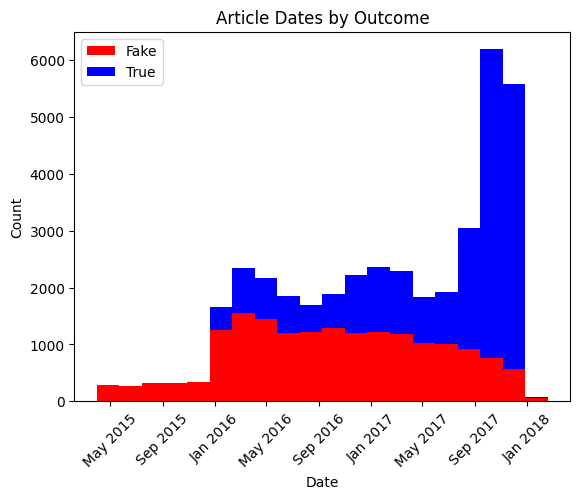

In [27]:
# Split data into categories
fake_data = all_data[all_data["outcome"] == "Fake"]["date"]
true_data = all_data[all_data["outcome"] == "True"]["date"]

# Plot a histogram
plt.hist([fake_data, true_data], bins = 20, stacked = True, label = ["Fake", "True"], color = ["r", "b"])

# Format dates
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Format plot
plt.title("Article Dates by Outcome")
plt.xlabel("Date")
plt.ylabel("Count")
plt.xticks(rotation = 45)
plt.legend()

In [28]:
# We now remove the subject and date columns as we just want to train on text
all_data = all_data.drop(columns = ["subject", "date"])

all_data.head()

,outcome,title_text
0,Fake,Trump Calls For This Racist Policy To Be Force...
1,True,Republican ex-defense secretary Cohen backs Hi...
2,Fake,"TEACHER QUITS JOB After 5th, 6th Grade Muslim ..."
3,Fake,LAURA INGRAHAM RIPS INTO THE PRESS…Crowd Goes ...
4,True,Germany's Merkel suffers state vote setback as...


In [29]:
# What is x and what is y?
x = "title_text"
y = "outcome"

In [30]:
# Do a stratified train/val/test split
x_train_val, x_test, y_train_val, y_test = train_test_split(all_data[x], all_data[y], test_size = 1 / 10, random_state = 1, shuffle = True, stratify = all_data[y])
x_train, x_val, y_train, y_val = train_test_split(x_train_val, y_train_val, test_size = 1 / 9, random_state = 1, shuffle = True, stratify = y_train_val)

In [ ]:
'''
TODO for preprocessing:
- Create embeddings
'''

'''
TODO when new data comes in through the website:
- Replace newlines (\n) with spaces in title and text
- Strip extra white space from title and text
- Apply ftfy to title and text
- Apply text_start_pattern to text
- Apply title_end_pattern to title
- Combine title and text with \n between
'''